# **Cumulative Antarctic freshwater projections under SSP126 and SSP585**

*Integrated whole-ice-sheet freshwater contribution by 2100 and 2300*

For an interactive version of this page please visit the Google Colab: [Open in Google Colab](https://colab.research.google.com/drive/1GM4xuw41Ag2gJqOj98cFjiFdgJOalV5_)

*(To open link in new tab press Ctrl + click)*

Alternatevly this notebook can be opened with Binder by following the link: [Cumulative Antarctic freshwater projections under SSP126 and SSP585](https://mybinder.org/v2/gh/s4oceanice/literacy.s4oceanice/main?urlpath=%2Fdoc%2Ftree%2Fnotebooks_binder%2FSSP126vsSSP585_projection.ipynb)

**Scientific background**

The Antarctic Ice Sheet is one of the major contributors to future sea-level change. Variations in ice-sheet mass balance and freshwater release influence the Southern Ocean, affecting ocean circulation, water-mass formation and climate feedbacks.

Comparing projections under a low-emissions scenario (SSP126) and a high-emissions scenario (SSP585) provides insight into the potential long-term response of the Antarctic cryosphere to future climate change.


**Notebook objectives**

This notebook enables users to:

- retrieve whole-Antarctic freshwater projections;
- isolate the median net mass-balance series;
- calculate cumulative values from 1990;
- compare SSP126 and SSP585;
- summarize cumulative contributions by 2100 and 2300.

**Dataset description**

The datasets are accessed directly from the **OCEAN:ICE ERDDAP server** at the following link:
- **Low-emission scenario** (SSP126 dataset): https://er1.s4oceanice.eu/erddap/griddap/SSP126_FWF_1990_2300_AIS
- **High-emission scenario** (SSP585 dataset): https://er1.s4oceanice.eu/erddap/griddap/SSP585_FWF_1990_2300_AIS

Depending on the notebook, the data represent Antarctic Ice Sheet projections, freshwater fluxes or derived quantities produced by climate-model simulations.

The notebooks retrieve the data, perform the necessary preprocessing steps and generate interactive visualizations that can be used for exploratory analysis.


**How to use this notebook**

1. Run the code cells sequentially from top to bottom.
2. Wait for the remote dataset to be downloaded and processed.
3. Use the available menus, sliders, or map controls to select the variables and periods of interest.
4. Read the interpretation guidance before drawing scientific conclusions from the visualizations.

The notebook retrieves data from remote services. An active internet connection is therefore required.

**1. Software environment**

The first code cell imports the data-processing libraries used by the cumulative calculation.

In [ ]:
# @title
import pandas as pd
import numpy as np

**2. Data retrieval and cumulative calculation**

The next section downloads each scenario, removes the units row, identifies the relevant columns, converts time to integer years, filters the median quantile, orders the values chronologically, and calculates the cumulative series.


In [ ]:
# @title

# URLs
urls = {
    'SSP126': "https://er1.s4oceanice.eu/erddap/griddap/SSP126_FWF_1990_2300_AIS.csv?Net_Mass_Balance%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(0.0):1:(0.0)%5D,Surface_Meltwater_Runoff_Fluxes%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(0.0):1:(0.0)%5D,Sub_Shelf_Melt_Fluxes%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(0.0):1:(0.0)%5D,Calving_Fluxes%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(0.0):1:(0.0)%5D",
    'SSP585': "https://er1.s4oceanice.eu/erddap/griddap/SSP585_FWF_1990_2300_AIS.csv?Net_Mass_Balance%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(0.0):1:(0.0)%5D,Surface_Meltwater_Runoff_Fluxes%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(0.0):1:(0.0)%5D,Sub_Shelf_Melt_Fluxes%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(0.0):1:(0.0)%5D,Calving_Fluxes%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(0.0):1:(0.0)%5D"
}

def process_freshwater(url):
    # Load data and remove the unit row
    df = pd.read_csv(url, skiprows=[1])

    # Try to identify the columns (ERDDAP sometimes uses names such as 'time (UTC)')
    time_col = [c for c in df.columns if 'time' in c.lower()][0]
    quantile_col = [c for c in df.columns if 'quantile' in c.lower()][0]
    mass_col = 'Net_Mass_Balance'

    # Convert time to years
    df['year'] = pd.to_numeric(df[time_col], errors='coerce')

    # Filter using the median (0.5 quantile) to avoid temporal duplicates
    df_med = df[df[quantile_col].astype(float) == 0.5].copy()

    # Sort by year
    df_med = df_med.sort_values('year')

    # Cumulative calculation starting from 1990
    # Assume the values represent annual fluxes (Gt/yr)
    #  Note: if the data are anomalies relative to a baseline, the calculation represents the cumulative anomaly.
    def get_sum(target_year):
        mask = (df_med['year'] >= 1990) & (df_med['year'] <= target_year)
        return df_med.loc[mask, mass_col].sum()

    return get_sum(2100), get_sum(2300)

results = {}
for scenario, url in urls.items():
    try:
        results[scenario] = process_freshwater(url)
    except Exception as e:
        print(f"Error while processing {scenario}: {e}")

print("\n--- CUMULATIVE FRESHWATER PROJECTION (Gt) ---")
print("Values based on the Net Mass Balance (0.5 quantile/median) since 1990")
for sc, vals in results.items():
    print(f"\nScenario {sc}:")
    print(f"  • Total by 2100: {vals[0]:,.1f} Gt")
    print(f"  • Totale by 2300: {vals[1]:,.1f} Gt")


--- CUMULATIVE FRESHWATER PROJECTION (Gt) ---
Values based on the Net Mass Balance (0.5 quantile/median) since 1990

Scenario SSP126:
  • Total by 2100: -6,384.6 Gt
  • Totale by 2300: -65,293.0 Gt

Scenario SSP585:
  • Total by 2100: -764.0 Gt
  • Totale by 2300: -651,582.7 Gt


**3. Endpoint comparison**

The final code section compares the absolute cumulative values estimated by 2100 and 2300 using a grouped bar chart.


**Results visualization**

The bars summarize the cumulative freshwater contribution calculated for each scenario at two endpoint years.

The visualization emphasizes the difference between near-term and long-term accumulation and the increasing divergence that may occur after 2100.

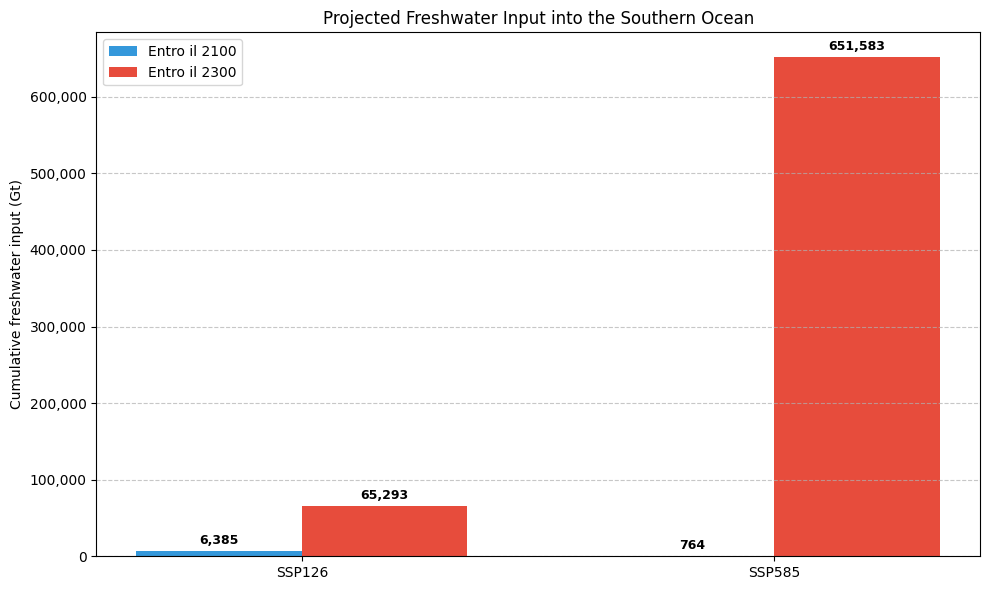

In [ ]:
# @title
import matplotlib.pyplot as plt

# Prepare the data from the previously generated 'results' dictionary
# Use the absolute value because ice sheet mass loss corresponds to freshwater input into the ocean
scenarios = list(results.keys())
vals_2100 = [abs(results[s][0]) for s in scenarios]
vals_2300 = [abs(results[s][1]) for s in scenarios]

x = np.arange(len(scenarios))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, vals_2100, width, label='Entro il 2100', color='#3498db')
rects2 = ax.bar(x + width/2, vals_2300, width, label='Entro il 2300', color='#e74c3c')

# Add labels and annotations
ax.set_ylabel('Cumulative freshwater input (Gt)')
ax.set_title('Projected Freshwater Input into the Southern Ocean')
ax.set_xticks(x)
ax.set_xticklabels(scenarios)
ax.legend()

# Format the Y-axis for better readability
ax.ticklabel_format(style='plain', axis='y')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Labels above the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{:,.0f}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Interpretation guidance**

The generated figures should be interpreted by comparing the projected behaviour under the two emissions scenarios. Differences between SSP126 and SSP585 illustrate the influence of future greenhouse-gas emissions, whereas spatial and temporal variability reflects the heterogeneous response of the Antarctic Ice Sheet.

These visualizations are intended for exploratory analysis and should be interpreted together with the accompanying metadata and modelling documentation.

**Additional resources and acknowledgement**

Python libraries used in this notebook:

- [pandas](https://pandas.pydata.org/docs/) for data processing
- [matplotlib](https://matplotlib.org/stable/index.html) for plotting
- [ipywidgets](https://ipywidgets.readthedocs.io/) for interactive control.

This work has received funding from the European Union Horizon Europe project **OCEAN:ICE (Ocean-Cryosphere Exchanges in ANtarctica: Impacts on Climate and the Earth System)** under Grant Agreement No. 101060452. The datasets are distributed through the OCEAN:ICE ERDDAP infrastructure.

<center>
  <div style="display: flex; justify-content: center; align-items: flex-start; gap: 80px;">
    <img src="https://ocean-ice.eu/wp-content/uploads/2025/02/TO-USE-RGB-for-digital-materials-V.png" height="140" style="margin-top: 50px;"/>
    <img src="https://ocean-ice.eu/wp-content/uploads/2025/02/UKRI-logo-1.png" height="100"/>
    <img src="https://ocean-ice.eu/wp-content/uploads/2023/06/logo-polar-cluster-2.png" height="100"/>
  </div>
</center>